# Now Let Us Finally take a Look at What Our Plot and Errors Look like #

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binned_statistic
from scipy.stats import linregress

In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_tripp_uncorrected.csv")
print(df.columns)

Index(['ZTF_Unnamed: 0', 'ztfname', 'ZTF_redshift', 'ZTF_redshift_err',
       'ZTF_source', 'ZTF_t0', 'ZTF_x0', 'ZTF_x1', 'ZTF_c', 'ZTF_t0_err',
       'ZTF_x0_err', 'ZTF_x1_err', 'ZTF_c_err', 'ZTF_cov_t0_x0',
       'ZTF_cov_t0_x1', 'ZTF_cov_t0_c', 'ZTF_cov_x0_x1', 'ZTF_cov_x0_c',
       'ZTF_cov_x1_c', 'ZTF_mwebv', 'ZTF_mwr_v', 'ZTF_mwebv_err',
       'ZTF_fitprob', 'ZTF_ra', 'ZTF_dec', 'ZTF_sn_type', 'ZTF_sub_type',
       'ZTF_lccoverage_flag', 'ZTF_fitquality_flag', 'ZTF_iau_name',
       'ZTF_frac_fitted', 'ZTF_ra_host_global', 'ZTF_dec_host_global',
       'ZTF_mass_global', 'ZTF_mass_err_global', 'ZTF_restframe_gz_global',
       'ZTF_restframe_gz_err_global', 'ZTF_d_dlr_global', 'ZTF_mass_local',
       'ZTF_mass_err_local', 'ZTF_restframe_gz_local',
       'ZTF_restframe_gz_err_local', 'ZTF_DESI_METADATA_ang_sep_arcsec',
       'DESI_METADATA_TARGETID', 'DESI_METADATA_LS_ID',
       'DESI_METADATA_SPECTYPE', 'DESI_METADATA_RA', 'DESI_METADATA_DEC',
       'DESI_METADATA_DESI

# Helper Function That Plots The Scatter with Error Bars #


Note that there is now a new way to bin the data here:


### Binned residuals and bin-level error bars

For each host-galaxy variable $x$, we bin the data into $N_{\rm bin}$ intervals along the $x$-axis. In bin $k$, let the set of supernova Hubble residuals be $\{\Delta\mu_i\}_{i=1}^{N_k}$, where $N_k$ is the number of objects in that bin. We plot the binned point as the mean residual in the bin,

$
\overline{\Delta\mu}_k=\frac{1}{N_k}\sum_{i=1}^{N_k}\Delta\mu_i,
$

evaluated at the bin center

$
x_k = \frac{1}{2}\left(x_{k,\min}+x_{k,\max}\right).
$

To represent the *spread* of residuals within each bin (rather than the uncertainty on the mean), the error bar for bin $k$ is taken to be the sample standard deviation of the residuals in that bin,

$
\sigma_{k,\rm bin}=\sqrt{\frac{1}{N_k-1}\sum_{i=1}^{N_k}\left(\Delta\mu_i-\overline{\Delta\mu}_k\right)^2}.
$

This choice yields error bars that reflect the intrinsic dispersion (plus measurement scatter) of $\Delta\mu$ among supernovae within each $x$-bin, and therefore does not shrink artificially as $N_k$ becomes large (in contrast to the standard error on the mean, $\sigma_{\overline{\Delta\mu}} \propto 1/\sqrt{N_k}$).

In [3]:
# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.

nbins = 10

def scatter_with_errors(ax, xcol, nbins=None, xerr_col=None, xerr_direct_col=None):

    # Raw values
    x = df[xcol]
    y = df["residuals"]
    yerr = df["ZTF_sigma_mu"]
    
    # Optional horizontal error bars
    if xerr_col is not None:
        xerr = 1.0 / np.sqrt(df[xerr_col])
    # accomodation function for when the xerr is already directly given
    # as part of the SALT2 Curve data release. 
    elif xerr_direct_col is not None: 
        xerr = df[xerr_direct_col]
    else:
        xerr = None #has to be parsed or will crash errorbar function.

    # --- sigma clipping in y (vertical axis) ---
    # NOTE: sigma clipping has been moved OUTSIDE this function.
    # This function now assumes `mask` already includes whatever global sigma-clip
    # (or other cleaning) you want. In other words: this function only plots.
    #
    # UPDATE: we no longer pass a mask into this function because we now DROP
    # any unwanted rows upstream (sigma-clip + physical cuts). Therefore the
    # dataframe `df` is already the final cleaned sample when this function is called.

    # --- scatter cloud ---
    ax.scatter(x, y, **point_kwargs)

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    ax.errorbar(
        x, y, yerr=yerr, xerr = xerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.5,
        alpha=0.25,
        zorder=2,
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange")

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.
    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # If a bin is empty, skip it (avoid divide-by-zero)
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]

        # inverse-variance weights
        w = 1.0 / (err_bin**2)

        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)

        # propagated error on the mean
        y_mean = np.mean(y_bin)
        err_spread = np.std(y_bin, ddof=1)   # spread of points in the bin
        
        binned_y.append(y_mean)
        binned_yerr.append(err_spread)

    # Convert to arrays and only plot finite bins
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color="blue",
        markersize=7,
        capsize=3,
        zorder=5  # Keeps the data looking on top
    )

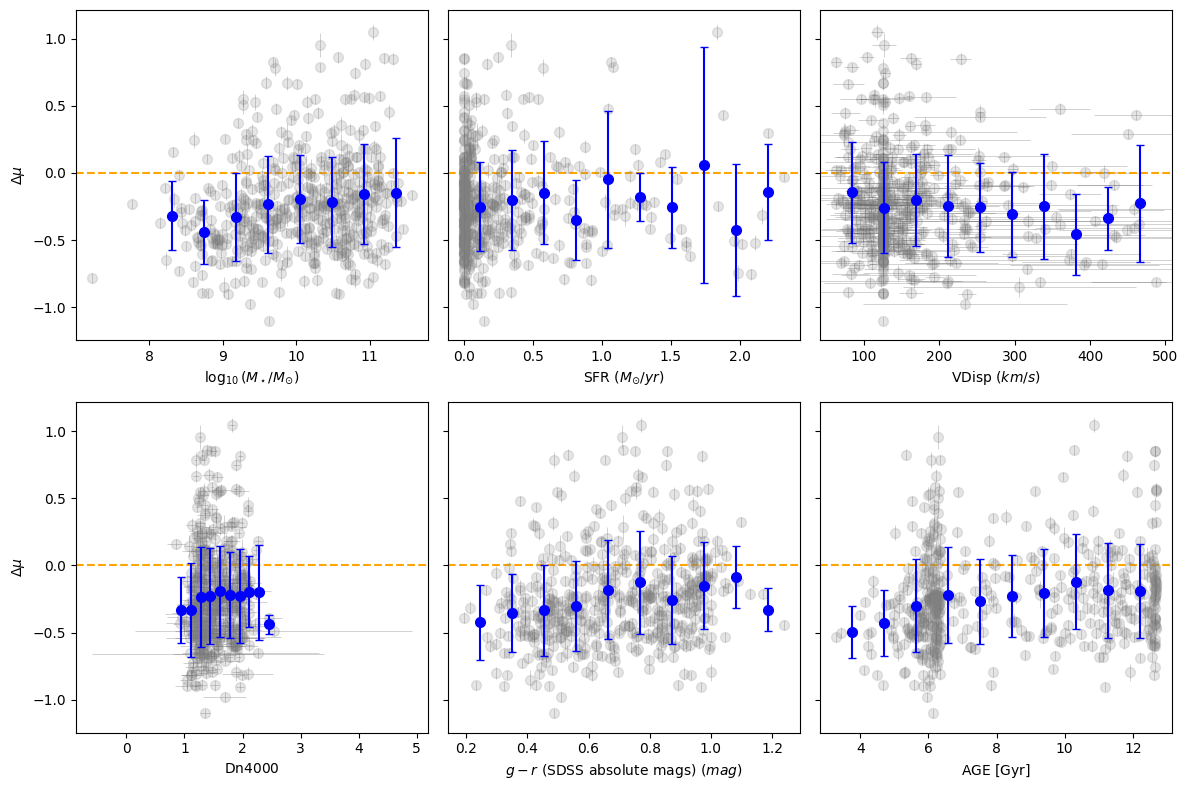

In [4]:
# ****************************************************************************
# ----------------------------------------------------------------------------
# Set up 2x3 grid - RESIDUALS + LIGHT CURVE PARAMETERS + ERRORS + BINS w/t ERRORS
# ----------------------------------------------------------------------------
# ****************************************************************************

# global number of bins
nbins = 10

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)   

# --------------------------------------
# 1) LOGMSTAR
# --------------------------------------
ax = axes[0]

# # finite values mask (same as before)
# mask_logm = np.ones(len(df), dtype=bool)
# print(np.sum(mask_logm), "SNe after LOGMSTAR cut.")

# NOTE: we no longer define masks here because we now DROP any unwanted rows
# upstream (sigma-clip + physical cuts). Therefore the dataframe `df` is already
# the final cleaned sample when plotting.

# Use helper function with binning ON
scatter_with_errors(ax, "DESI_FASTSPEC_LOGMSTAR", nbins)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 2) SFR (cut SFR > 2.5)
# --------------------------------------
ax = axes[1]

# Exclude SFR > 2.5
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "DESI_FASTSPEC_SFR", nbins=nbins)

ax.set_xlabel(r"${\rm SFR}\ (M_{\odot}/yr)$")

# --------------------------------------
# 3) VDISP
# --------------------------------------
ax = axes[2]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "DESI_FASTSPEC_VDISP", nbins, "DESI_FASTSPEC_VDISP_IVAR")

ax.set_xlabel(r"${\rm VDisp }\  (km/s) $")

# --------------------------------------
# 4) DN4000  (cut DN4000 < 0.5)
# --------------------------------------
ax = axes[3]

# keep only finite values AND DN4000 >= 0.5
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "DESI_FASTSPEC_DN4000", nbins, "DESI_FASTSPEC_DN4000_IVAR")

ax.set_xlabel(r"${\rm Dn4000}$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 5) SDSS g - r
# --------------------------------------
ax = axes[4]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "DESI_FASTSPEC_g_minus_r", nbins=nbins)

ax.set_xlabel(r"$g - r~{\rm (SDSS ~ absolute ~ mags)}\ (mag)$")

# --------------------------------------
# 6) AGE  (cut AGE < 2)
# --------------------------------------
ax = axes[5]

# keep only finite AGE and AGE >= 2
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "DESI_FASTSPEC_AGE", nbins=nbins)

ax.set_xlabel(r"${\rm AGE}\ [{\rm Gyr}]$")


fig.tight_layout()
plt.show()



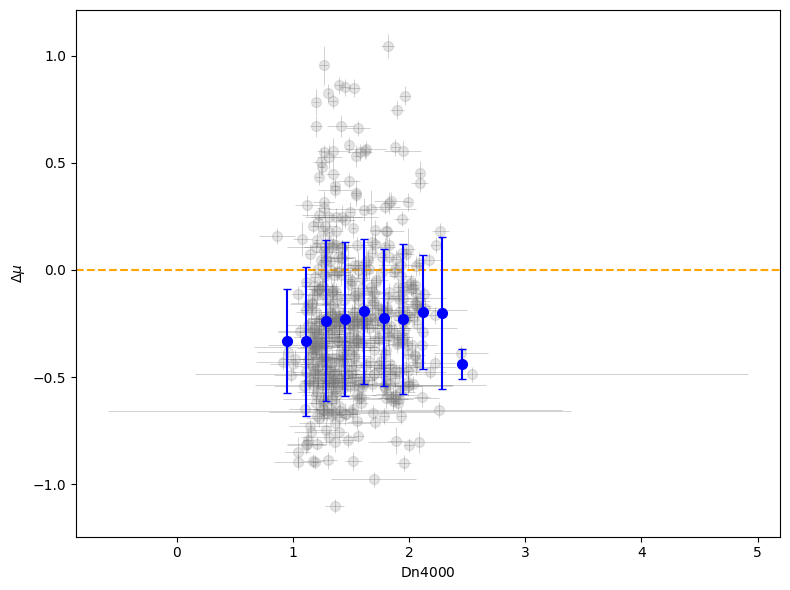

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter_with_errors(ax, "DESI_FASTSPEC_DN4000", nbins, "DESI_FASTSPEC_DN4000_IVAR")

ax.set_xlabel(r"${\rm Dn4000}$")
ax.set_ylabel(r"$\Delta \mu$")

fig.tight_layout()
plt.show()

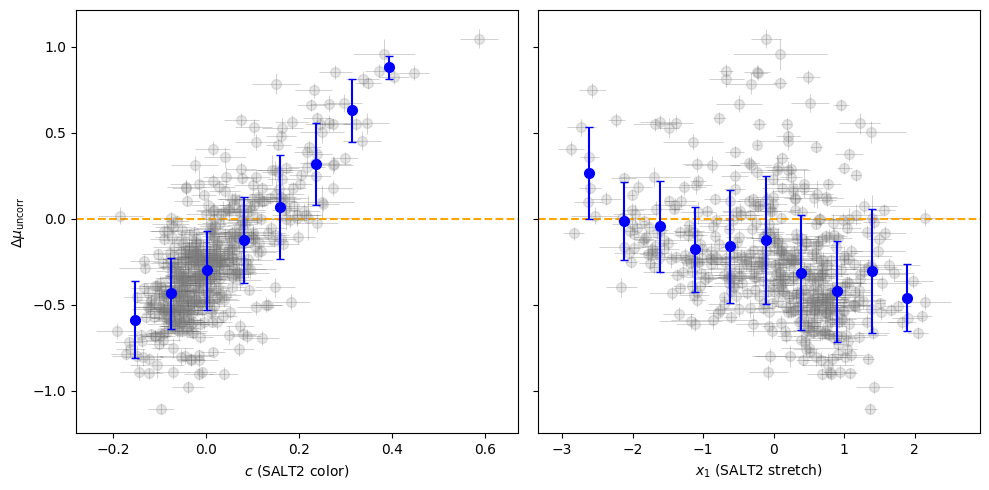

In [6]:
# ****************************************************************************
# ----------------------------------------------------------------------------
# Set up 1x2 grid - LIGHT CURVE PARAMETERS (color, stretch) vs UNCORRECTED RESIDUALS
# ----------------------------------------------------------------------------
# ****************************************************************************

nbins = 10

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)

# --------------------------------------
# 1) COLOR (ZTF_c)
# --------------------------------------
ax = axes[0]

scatter_with_errors(ax, "ZTF_c", nbins, xerr_direct_col="ZTF_c_err")

ax.set_xlabel(r"$c$ (SALT2 color)")
ax.set_ylabel(r"$\Delta \mu_{\rm uncorr}$")

# --------------------------------------
# 2) STRETCH (ZTF_x1)
# --------------------------------------
ax = axes[1]

scatter_with_errors(ax, "ZTF_x1", nbins, xerr_direct_col="ZTF_x1_err")

ax.set_xlabel(r"$x_1$ (SALT2 stretch)")

fig.tight_layout()
plt.show()

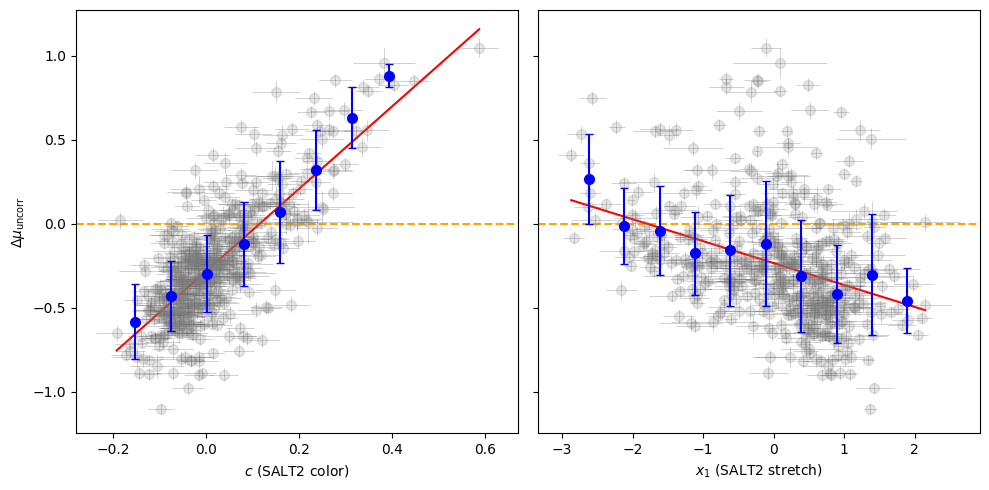

Recovered beta  (color slope):   2.457 |  Ginolin+2024: 3.050
Recovered alpha (stretch slope): -0.131 |  Ginolin+2024: 0.161


In [7]:
# ****************************************************************************
# ----------------------------------------------------------------------------
# Set up 1x2 grid - LIGHT CURVE PARAMETERS (color, stretch) vs UNCORRECTED RESIDUALS
# ----------------------------------------------------------------------------
# ****************************************************************************

nbins = 10

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)

# --------------------------------------
# 1) COLOR (ZTF_c)
# --------------------------------------
ax = axes[0]

scatter_with_errors(ax, "ZTF_c", nbins, xerr_direct_col="ZTF_c_err")

# Linear fit
x_c = df["ZTF_c"]
y   = df["residuals"]
slope_c, intercept_c, _, _, _ = linregress(x_c, y)
x_fit = np.linspace(x_c.min(), x_c.max(), 200)
ax.plot(x_fit, slope_c * x_fit + intercept_c, color="red", lw=1.5)

ax.set_xlabel(r"$c$ (SALT2 color)")
ax.set_ylabel(r"$\Delta \mu_{\rm uncorr}$")

# --------------------------------------
# 2) STRETCH (ZTF_x1)
# --------------------------------------
ax = axes[1]

scatter_with_errors(ax, "ZTF_x1", nbins, xerr_direct_col="ZTF_x1_err")

# Linear fit
x_x1 = df["ZTF_x1"]
slope_x1, intercept_x1, _, _, _ = linregress(x_x1, y)
x_fit = np.linspace(x_x1.min(), x_x1.max(), 200)
ax.plot(x_fit, slope_x1 * x_fit + intercept_x1, color="red", lw=1.5)
ax.set_xlabel(r"$x_1$ (SALT2 stretch)")
fig.tight_layout()
plt.show()

print(f"Recovered beta  (color slope):   {slope_c:.3f} |  Ginolin+2024: 3.050")
print(f"Recovered alpha (stretch slope): {slope_x1:.3f} |  Ginolin+2024: 0.161")